In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('D:/Data Analysis/Space Mission Analysis/Dataset/Space_Missions_Dataset.csv')

In [3]:
df['Launch_Year'] = df['Launch_Date'].str.split("-").str[0]

In [4]:
df.columns

Index(['Mission_ID', 'Mission_Name', 'Agency', 'Country_Region', 'Agency_Type',
       'Program_Type', 'Mission_Category', 'Sub_Category', 'Launch_Date',
       'End_Date', 'Duration', 'Launch_Vehicle', 'Launch_Site', 'Status',
       'Mission_Phase', 'Crew_Type', 'Crew_Members', 'Destination',
       'Objective', 'Key_Achievement', 'Cost_USD_Million', 'Partner_Agencies',
       'Data_Returned', 'Failure_Reason', 'Mission_Outcome_Detail',
       'Reference_URL', 'Launch_Year'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Mission_ID              10500 non-null  object 
 1   Mission_Name            10500 non-null  object 
 2   Agency                  10500 non-null  object 
 3   Country_Region          10500 non-null  object 
 4   Agency_Type             10500 non-null  object 
 5   Program_Type            10500 non-null  object 
 6   Mission_Category        10500 non-null  object 
 7   Sub_Category            10500 non-null  object 
 8   Launch_Date             10500 non-null  object 
 9   End_Date                5796 non-null   object 
 10  Duration                10266 non-null  object 
 11  Launch_Vehicle          10500 non-null  object 
 12  Launch_Site             10500 non-null  object 
 13  Status                  10500 non-null  object 
 14  Mission_Phase           10500 non-null

In [6]:
df.isnull().sum()

Mission_ID                   0
Mission_Name                 0
Agency                       0
Country_Region               0
Agency_Type                  0
Program_Type                 0
Mission_Category             0
Sub_Category                 0
Launch_Date                  0
End_Date                  4704
Duration                   234
Launch_Vehicle               0
Launch_Site                  0
Status                       0
Mission_Phase                0
Crew_Type                    0
Crew_Members              7863
Destination                  0
Objective                    0
Key_Achievement            321
Cost_USD_Million             0
Partner_Agencies          6164
Data_Returned             1560
Failure_Reason            9339
Mission_Outcome_Detail       0
Reference_URL                0
Launch_Year                  0
dtype: int64

In [7]:
df['Mission_Name'].value_counts()

Mission_Name
CRS-10                          2
Crew-7                          2
Mars Express                    2
CRS-30                          2
CRS-25                          2
                               ..
CNES Sun/Solar Mission 3532     1
NASA Deep Space Mission 3533    1
CNSA Sun/Solar Mission 3534     1
DLR Mars Mission 3535           1
CNSA Sun/Solar Mission 10500    1
Name: count, Length: 10477, dtype: int64

In [13]:
df['Status'].value_counts()

Status
Success            4314
Ongoing            3144
Upcoming           1560
Failed              909
Partial Success     573
Name: count, dtype: int64

In [12]:
df['Status'].value_counts().sum()

10500

In [22]:
df[(df['Status'] != 'Ongoing') & (df['Status'] != 'Upcoming')]['Status'].value_counts().sum()

5796

In [24]:
df[df['Status'] == 'Upcoming']['Status'].value_counts().sum()

1560

In [26]:
df[df['Status'] == 'Ongoing']['Status'].value_counts().sum()

3144

In [8]:
df['Cost_USD_Million'] = pd.to_numeric(
    df['Cost_USD_Million'],
    errors='coerce'
)

f"${df['Cost_USD_Million'].mean():,.2f} Million"

'$7,383.78 Million'

In [6]:
print(df['Agency'].nunique())

27


In [10]:
df['Country_Region'].nunique()

10

In [13]:
df['Launch_Vehicle'].nunique()

44

In [21]:
df['Status'].value_counts()

Status
Success            4314
Ongoing            3144
Upcoming           1560
Failed              909
Partial Success     573
Name: count, dtype: int64

In [24]:
succ = df[df['Status'] == 'Success']['Status'].value_counts().sum()
fail = df[(df['Status'] == 'Failed') | (df['Status'] == 'Partial Success')]['Status'].value_counts().sum()

total = succ + fail

perc = ((total - fail)/total)*100

print(perc)

74.43064182194618


In [25]:
completed = df[
    df['Status'].isin([
        'Success',
        'Failed',
        'Partial Success'
    ])
]

success_rate = (
    (completed['Status'] == 'Success').sum()
    / len(completed)
) * 100

In [28]:
df['Mission_Category'].value_counts()

Mission_Category
Mercury                    597
Deep Space                 582
SmallSat                   579
Saturn                     575
Moon                       571
Mars                       564
Communication Satellite    563
Crewed Spaceflight         559
CubeSat                    559
Telescope                  559
Jupiter                    558
Sun/Solar                  544
ISS                        543
Technology Demo            542
Asteroid                   537
Earth Orbit                537
Venus                      515
Earth Observation          512
Sounding Rocket            504
Name: count, dtype: int64

In [15]:
Year_val = df['Launch_Year'].value_counts().sort_index().values

In [16]:
Year = df['Launch_Year'].value_counts().sort_index().index

In [20]:
df['Launch_Year'].dtype

dtype('O')

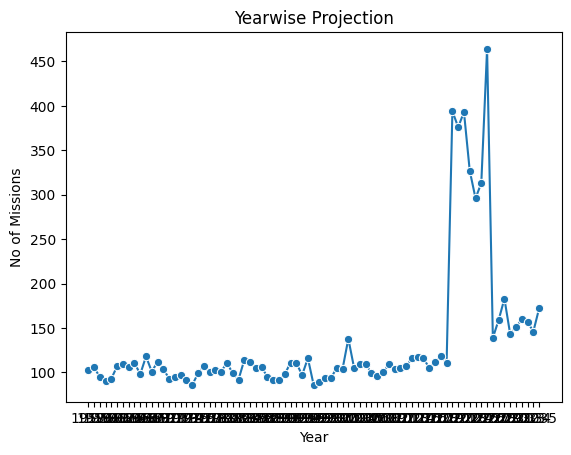

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=Year, y=Year_val, marker="o")

plt.title("Yearwise Projection")
plt.xlabel("Year")
plt.ylabel("No of Missions")
plt.show()

In [18]:
import plotly.express as px

fig = px.line(
    x=Year,
    y=Year_val,
    markers=True,
    labels={
        "x": "Year",
        "y": "No of Missions"
    },
    title="Yearwise Missions"
)

fig.update_traces(
    hovertemplate=
    "Year: %{x}<br>" +
    "Missions: %{y}<extra></extra>"
)

fig.show()

In [21]:
Succ_Year = df[df['Status'] == 'Success']['Launch_Year'].value_counts().sort_index().index

In [22]:
Succ_val = df[df['Status'] == 'Success']['Launch_Year'].value_counts().sort_index().values

In [23]:
import plotly.express as px

fig = px.line(
    x=Succ_Year,
    y=Succ_val,
    markers=True,
    labels={
        "x": "Year",
        "y": "No of Successful Missions"
    },
    title="Yearwise  Successsfull Missions"
)

fig.update_traces(
    hovertemplate=
    "Year: %{x}<br>" +
    "Missions: %{y}<extra></extra>"
)

fig.show()

In [6]:
status_val = df['Status'].value_counts().values

In [8]:
status = df['Status'].value_counts().index

Text(0.5, 1.0, 'Status Distribution')

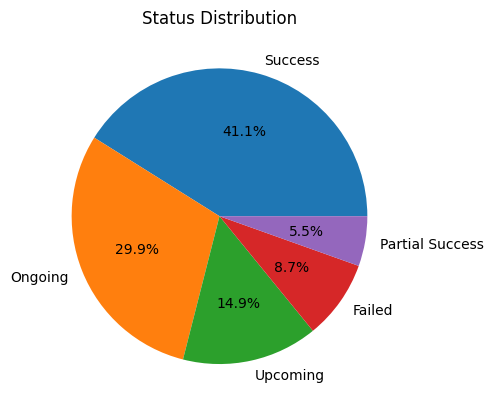

In [11]:
plt.pie(status_val,labels=status,autopct='%1.1f%%')
plt.title('Status Distribution')

In [14]:
miss_val = df['Mission_Category'].value_counts().values

In [15]:
miss = df['Mission_Category'].value_counts().index

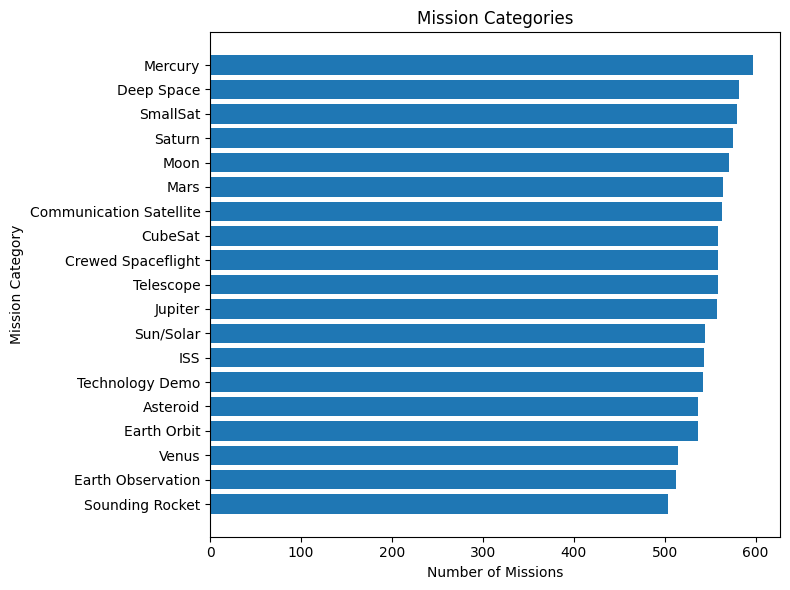

In [18]:
category_counts = (
    df['Mission_Category']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 6))

plt.barh(
    category_counts.index,
    category_counts.values
)

plt.xlabel("Number of Missions")
plt.ylabel("Mission Category")
plt.title("Mission Categories")

plt.tight_layout()
plt.show()

In [19]:
df['Destination'].value_counts()

Destination
Mercury                    597
Deep Space                 582
SmallSat                   579
Saturn                     575
Moon                       571
Mars                       564
Communication Satellite    563
Crewed Spaceflight         559
CubeSat                    559
Telescope                  559
Jupiter                    558
Sun/Solar                  544
ISS                        543
Technology Demo            542
Asteroid                   537
Earth Orbit                537
Venus                      515
Earth Observation          512
Sounding Rocket            504
Name: count, dtype: int64

In [21]:
df['Country_Region'].value_counts()[:5]

Country_Region
USA       2796
Russia     918
China      905
Europe     895
Japan      891
Name: count, dtype: int64

In [5]:
df.columns

Index(['Mission_ID', 'Mission_Name', 'Agency', 'Country_Region', 'Agency_Type',
       'Program_Type', 'Mission_Category', 'Sub_Category', 'Launch_Date',
       'End_Date', 'Duration', 'Launch_Vehicle', 'Launch_Site', 'Status',
       'Mission_Phase', 'Crew_Type', 'Crew_Members', 'Destination',
       'Objective', 'Key_Achievement', 'Cost_USD_Million', 'Partner_Agencies',
       'Data_Returned', 'Failure_Reason', 'Mission_Outcome_Detail',
       'Reference_URL', 'Launch_Year'],
      dtype='object')

In [6]:
df['Country_Region'].value_counts()

Country_Region
USA        2796
Russia      918
China       905
Europe      895
Japan       891
Germany     849
India       841
Italy       816
France      812
Canada      777
Name: count, dtype: int64

In [4]:
df1 = df[df['Country_Region'] == 'USA']

In [14]:
len(df1)

2796

In [10]:
year = df1['Launch_Year'].value_counts().index

In [9]:
year_val = df1['Launch_Year'].value_counts().values

In [11]:
import plotly.express as px

fig = px.line(
    x=year,
    y=year_val,
    markers=True,
    labels={
        "x": "Year",
        "y": "No of Missions"
    },
    title="Yearwise Missions"
)

fig.update_traces(
    hovertemplate=
    "Year: %{x}<br>" +
    "Missions: %{y}<extra></extra>"
)

fig.show()

In [17]:
df['Status'].value_counts()

Status
Success            4314
Ongoing            3144
Upcoming           1560
Failed              909
Partial Success     573
Name: count, dtype: int64

In [25]:
df1[df1['Status'] == 'Upcoming']['Status'].value_counts().sum()

389

In [26]:
df1[df1['Status'] == 'Ongoing']['Status'].value_counts().sum()

870

In [28]:
completed = df1[
    df1['Status'].isin([
        'Success',
        'Failed',
        'Partial Success'
    ])
]

success_rate = (
    (completed['Status'] == 'Success').sum()
    / len(completed)
) * 100

print(success_rate)

75.01626545217958


In [30]:
df1['Launch_Vehicle'].value_counts().index[:1]

Index(['New Shepard'], dtype='object', name='Launch_Vehicle')

In [32]:
df1['Agency'].value_counts().index[:1]

Index(['NASA'], dtype='object', name='Agency')

In [5]:
df['Country_Region'].unique() 

array(['USA', 'Russia', 'China', 'Europe', 'India', 'Japan', 'France',
       'Germany', 'Italy', 'Canada'], dtype=object)

In [13]:
def Country_Stats(country):
    df2 = df[df['Country_Region'] == country]
    total_miss = len(df2)
    upcomming = df2[df2['Status'] == 'Upcoming']['Status'].value_counts().sum()
    ongoing = df2[df2['Status'] == 'Ongoing']['Status'].value_counts().sum()

    completed = df2[
    df2['Status'].isin([
        'Success',
        'Failed',
        'Partial Success'
        ])
    ]

    success_rate = (
        (completed['Status'] == 'Success').sum()
        / len(completed)
    )

    # top_vehicle = df2['Launch_Vehicle'].value_counts().index[:1]
    # top_agency = df2['Agency'].value_counts().index[:1]

    top_vehicle = df2['Launch_Vehicle'].mode().iloc[0]
    top_agency = df2['Agency'].mode().iloc[0]

    return {
        "total_missions": total_miss,
        "upcoming_missions": upcomming,
        "ongoing_missions": ongoing,
        "success_rate": success_rate,
        "top_vehicle": top_vehicle,
        "top_agency": top_agency
    }

In [14]:
Country_Stats('India')

{'total_missions': 841,
 'upcoming_missions': 118,
 'ongoing_missions': 232,
 'success_rate': 0.7209775967413442,
 'top_vehicle': 'GSLV',
 'top_agency': 'ISRO'}

In [12]:
df_agency = df[df['Agency'] == 'NASA']

In [15]:
completed = df[
    df['Status'].isin([
        'Success',
        'Failed',
        'Partial Success'
    ])
]

agency_stats = (
    completed
    .groupby('Agency')
    .agg(
        missions=('Status', 'count'),
        successes=('Status',
                   lambda x: (x == 'Success').sum())
    )
)

# Keep agencies with at least 20 missions
agency_stats = agency_stats[
    agency_stats['missions'] >= 20
]

agency_stats['success_rate'] = (
    agency_stats['successes']
    / agency_stats['missions']
) * 100

agency_stats = agency_stats.sort_values(
    'success_rate',
    ascending=False
)

print(agency_stats)

             missions  successes  success_rate
Agency                                        
CNSA              483        376     77.846791
Blue Origin       476        364     76.470588
SpaceX            521        396     76.007678
CSA               416        315     75.721154
ROSCOSMOS         540        407     75.370370
ESA               476        357     75.000000
JAXA              500        372     74.400000
ASI               445        325     73.033708
NASA              539        392     72.727273
DLR               472        343     72.669492
ISRO              491        354     72.097760
CNES              432        310     71.759259


In [16]:
df.head()

,Mission_ID,Mission_Name,Agency,Country_Region,Agency_Type,Program_Type,Mission_Category,Sub_Category,Launch_Date,End_Date,...,Destination,Objective,Key_Achievement,Cost_USD_Million,Partner_Agencies,Data_Returned,Failure_Reason,Mission_Outcome_Detail,Reference_URL,Launch_Year
0,NA-00001,Explorer 1,NASA,USA,Government,Technology Demo,Mercury,Orbiter,1976-01-12,1987-02-18,...,Mercury,Black hole imaging and stellar cataloguing,Debris impact damaged solar panels,7708.6,NaN,Partial,Debris impact damaged solar panels,Exceeded planned science return by 3x,https://www.nasa.gov/mission/explorer-1,1976
1,NA-00002,Pioneer 1,NASA,USA,Government,Human Spaceflight,Saturn,Flyby,1977-05-01,1984-07-15,...,Saturn,Orbital mechanics experiment for future missions,Detected water ice at target location,11802.2,SpaceX,Yes,NaN,Detected organic molecules at surface,https://www.nasa.gov/mission/pioneer-1,1977
2,NA-00003,Mercury-Redstone 1,NASA,USA,Government,Sounding Rocket,Earth Observation,Climate Study,1966-01-13,1969-12-13,...,Earth Observation,Gamma-ray burst detection and cataloguing,NaN,7836.7,NaN,Yes,NaN,Planned - objectives to be confirmed post-launch,https://www.nasa.gov/mission/mercury-redstone-1,1966
3,NA-00004,Freedom 7,NASA,USA,Government,Satellite,Mercury,Flyby,1987-07-06,1989-03-19,...,Mercury,Earth observation for disaster management,Demonstrated reusable rocket landing,10659.5,NaN,Partial,NaN,Failed to achieve orbit due to launch vehicle ...,https://www.nasa.gov/mission/freedom-7,1987
4,NA-00005,Friendship 7,NASA,USA,Government,Commercial,Telescope,Radio,2012-09-09,NaN,...,Telescope,Human lunar landing mission support,Discovered new geological features,4385.5,JAXA,Yes,NaN,Detected organic molecules at surface,https://www.nasa.gov/mission/friendship-7,2012


In [4]:
df3 = df[df['Country_Region'] == 'India']

In [ ]:
df3['']